In [2]:
import pandas as pd

# 1. Fusion des 2 fichiers 2024 et 2024

In [3]:
import os
os.chdir("C:/Users/carine/mars26_bds_immo")
print(os.getcwd())

C:\Users\carine\mars26_bds_immo


In [4]:
file_2024 = "data/raw/ValeursFoncieres-2024.txt"
file_2025 = "data/raw/ValeursFoncieres-2025.txt"

output_file = "data/raw/ValeursFoncieres-merged.txt"

In [5]:
import os
os.makedirs("data/raw", exist_ok=True)

In [6]:
with open(output_file, "w", encoding="utf-8") as out:

    for file in [file_2024, file_2025]:
        print(f"Traitement : {file}")

        with open(file, "r", encoding="utf-8") as f:
            for line in f:
                out.write(line)

Traitement : data/raw/ValeursFoncieres-2024.txt
Traitement : data/raw/ValeursFoncieres-2025.txt


In [7]:
print("Fusion terminée ✔️ fichier créé :", output_file)

Fusion terminée ✔️ fichier créé : data/raw/ValeursFoncieres-merged.txt


In [8]:
# 1. Chargement des données
# 2. Audit des colonnes
# 3. Nettoyage colonne par colonne
# 4. Feature engineering (si besoin)
# 5. Normalisation / encodage
# 6. Dataset final

# 2. Chargement des données

In [79]:
import pandas as pd
df = pd.read_csv(
    "data/raw/ValeursFoncieres-merged.txt",
    sep="|",
    dtype=str,
    low_memory=False
)

# 3. Audit des colonnes

## 3.1 Aperçu du DF

In [80]:
df.head()

,Identifiant de document,Reference document,1 Articles CGI,2 Articles CGI,3 Articles CGI,4 Articles CGI,5 Articles CGI,No disposition,Date mutation,Nature mutation,...,Surface Carrez du 5eme lot,Nombre de lots,Code type local,Type local,Identifiant local,Surface reelle bati,Nombre pieces principales,Nature culture,Nature culture speciale,Surface terrain
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,02/01/2024,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,P,NaN,99
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000002,03/01/2024,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,115
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,08/01/2024,Vente,...,NaN,0,NaN,NaN,NaN,NaN,NaN,S,NaN,497
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,03/01/2024,Vente,...,NaN,2,3,Dépendance,NaN,0,0,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,000001,03/01/2024,Vente,...,NaN,1,3,Dépendance,NaN,0,0,NaN,NaN,NaN


In [83]:
df.shape

(7214761, 43)

In [84]:
df.columns

Index(['Identifiant de document', 'Reference document', '1 Articles CGI',
       '2 Articles CGI', '3 Articles CGI', '4 Articles CGI', '5 Articles CGI',
       'No disposition', 'Date mutation', 'Nature mutation', 'Valeur fonciere',
       'No voie', 'B/T/Q', 'Type de voie', 'Code voie', 'Voie', 'Code postal',
       'Commune', 'Code departement', 'Code commune', 'Prefixe de section',
       'Section', 'No plan', 'No Volume', '1er lot',
       'Surface Carrez du 1er lot', '2eme lot', 'Surface Carrez du 2eme lot',
       '3eme lot', 'Surface Carrez du 3eme lot', '4eme lot',
       'Surface Carrez du 4eme lot', '5eme lot', 'Surface Carrez du 5eme lot',
       'Nombre de lots', 'Code type local', 'Type local', 'Identifiant local',
       'Surface reelle bati', 'Nombre pieces principales', 'Nature culture',
       'Nature culture speciale', 'Surface terrain'],
      dtype='str')

## Typage des colonnes
✔ tout en string = normal au départ
✔ pas une erreur de merge
✔ problème de typage uniquement
✔ étape suivante = preprocessing

Correction des types des colonnes au fil de l'analyse

In [88]:
df.dtypes

Identifiant de document       str
Reference document            str
1 Articles CGI                str
2 Articles CGI                str
3 Articles CGI                str
4 Articles CGI                str
5 Articles CGI                str
No disposition                str
Date mutation                 str
Nature mutation               str
Valeur fonciere               str
No voie                       str
B/T/Q                         str
Type de voie                  str
Code voie                     str
Voie                          str
Code postal                   str
Commune                       str
Code departement              str
Code commune                  str
Prefixe de section            str
Section                       str
No plan                       str
No Volume                     str
1er lot                       str
Surface Carrez du 1er lot     str
2eme lot                      str
Surface Carrez du 2eme lot    str
3eme lot                      str
Surface Carrez

## Analyse des valeurs manquantes

Certaines colonnes présentent plus de 90% de valeurs manquantes.
Ces colonnes concernent principalement des informations spécifiques
(lots multiples, surfaces Carrez, identifiants techniques).

Ces variables ne sont pas pertinentes pour l'analyse principale
et seront supprimées lors du preprocessing.

In [86]:
(df.isna().mean() * 100).sort_values(ascending=False)

Identifiant de document       99.999986
Reference document            99.999986
1 Articles CGI                99.999986
2 Articles CGI                99.999986
3 Articles CGI                99.999986
4 Articles CGI                99.999986
5 Articles CGI                99.999986
Identifiant local             99.999986
Surface Carrez du 5eme lot    99.970408
Surface Carrez du 4eme lot    99.917572
No Volume                     99.764802
5eme lot                      99.747878
Surface Carrez du 3eme lot    99.672837
4eme lot                      99.455630
3eme lot                      98.344505
Surface Carrez du 2eme lot    97.043021
Nature culture speciale       95.524536
B/T/Q                         95.516719
Prefixe de section            95.139312
Surface Carrez du 1er lot     90.864992
2eme lot                      90.586729
1er lot                       69.242197
Nombre pieces principales     40.840521
Surface reelle bati           40.840521
Code type local               40.778121


## Identifiants techniques

Identifiant de document       99.999986
Reference document            99.999986
Identifiant local             99.999986

Ces colonnes ne sont pas utiles pour l’analyse.
C’est un identifiant interne du fichier DVF (souvent un ID technique).
Il sert à :

tracer une mutation
éviter les doublons
audit / contrôle des données...


L’exploration des données (2024 et 2025) montre que ces colonnes sont entièrement non exploitables :

- `head()` → uniquement des valeurs manquantes (NaN)
- taux de valeurs manquantes proche de 100% selon les fichiers
- absence d’information exploitable pour l’analyse

---

### ❌ Décision

Ces colonnes seront supprimées car :
- elles sont totalement ou quasi totalement vides
- elles n’apportent aucune information métier
- elles ne sont pas utilisées dans l’analyse immobilière DVF

Colonnes à supprimer : 

Identifiant de document       99.999986
Reference document            99.999986
Identifiant local             99.999986

In [89]:
df["Identifiant de document"].isna().sum()

np.int64(7214760)

In [97]:
df["Identifiant de document"].head

<bound method NDFrame.head of 0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
          ... 
7214756    NaN
7214757    NaN
7214758    NaN
7214759    NaN
7214760    NaN
Name: Identifiant de document, Length: 7214761, dtype: str>

In [ ]:
df["Identifiant de document"].head

In [90]:
df["Identifiant de document"].nunique()

1

## Articles CGI
Colonnes administratives non utilisées en analyse. Les colonnes ont été supprimées

Les “Articles CGI” font référence au Code Général des Impôts.

👉 En pratique dans DVF :

ce sont des mentions fiscales / juridiques
liées à des exonérations ou régimes spécifiques
très peu exploitables sans contexte juridique avancé
## 🧾 Colonnes CGI (Code Général des Impôts)

### 📌 Colonnes analysées
- 1 Articles CGI à 5 Articles CGI

---

### 🔍 Observations
Les colonnes présentent un taux de valeurs manquantes quasi total (~99.9999%).  
Les premières lignes (`head()`) montrent uniquement des valeurs NaN.

---

### 🧠 Interprétation
Ces colonnes correspondent à des références fiscales et juridiques (CGI), rarement renseignées dans les données DVF standard et non exploitable dans une analyse immobilière classique.

---

### ❌ Décision
Les colonnes CGI sont supprimées car :
- quasi entièrement vides
- non exploitables statistiquement
- sans intérêt pour l’analyse du marché immobilier

---

In [ ]:
# 1 Articles CGI       A SUPPRIMER         99.999986
2 Articles CGI                99.999986
3 Articles CGI                99.999986
4 Articles CGI                99.999986
5 Articles CGI                99.999986

#cgi_cols = [
  "1 Articles CGI",
  "2 Articles CGI",
  "3 Articles CGI",
  "4 Articles CGI",
  "5 Articles CGI"
]

df = df.drop(columns=cgi_cols)

## No disposition
Identifiant de transaction interne. No disposition correspond à :

un numéro interne dans une même mutation DVF
permet de distinguer plusieurs lignes pour une même vente

Observations
- Valeurs manquantes : 0%
- Nombre de valeurs uniques : 312

---

### 🧠 Interprétation
Cette colonne est entièrement renseignée et sert à distinguer les différentes lignes au sein d’une même mutation immobilière.

Elle permet de gérer les cas où une vente contient plusieurs biens (lots ou parcelles).

Cependant, elle ne contient pas d’information économique ou descriptive sur les biens.

---
Cette colonne est utile si tu veux :

reconstruire des transactions complètes
faire du groupby sur mutation

👉 mais inutile si tu fais :

analyse prix
prix/m²
typologie des biens
marché immobilier global

A DECIDER - On peut toujours la supprimer dans ton cas, mais avec nuance :

✔️ utile techniquement
❌ inutile pour analyse économique

In [98]:
df["No disposition"].isna().mean() * 100

np.float64(0.0)

In [99]:
df["No disposition"].nunique()

312

## Date mutation
Date de vente du bien immobilier. 

Transformation en datetime
Avec conversion :

✔️ analyse des tendances immobilières
✔️ évolution des prix
✔️ comparaison année par année
✔️ saisonnalité des ventes


Analyse mensuelle des transactions immobilières

Le graphique combine :
- le volume de transactions (barres)
- la répartition mensuelle en pourcentage (courbes)

### 🧠 Interprétation
- les barres permettent d’observer l’activité globale du marché
- les courbes montrent la saisonnalité des transactions indépendamment du volume

### 📈 Conclusion
Cette double lecture permet de comparer à la fois :
- l’intensité du marché immobilier
- et la distribution des ventes dans l’année

A CONSERVER très important

In [100]:
df["Date mutation"].head(10)

0    02/01/2024
1    03/01/2024
2    08/01/2024
3    03/01/2024
4    03/01/2024
5    03/01/2024
6    03/01/2024
7    09/01/2024
8    09/01/2024
9    09/01/2024
Name: Date mutation, dtype: str

In [101]:
df["Date mutation"].isna().mean() * 100

np.float64(0.0)

In [102]:
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

In [25]:
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

In [103]:
df["Date mutation"].dt.year.value_counts().sort_index()

Date mutation
2024.0    1188231
2025.0    1256130
Name: count, dtype: int64

In [104]:
df["Date mutation"].dt.month.value_counts().sort_index()

Date mutation
1.0     153200
2.0     183280
3.0     208297
4.0     220233
5.0     224785
6.0     199549
7.0     209075
8.0     183042
9.0     190492
10.0    226478
11.0    207578
12.0    238352
Name: count, dtype: int64

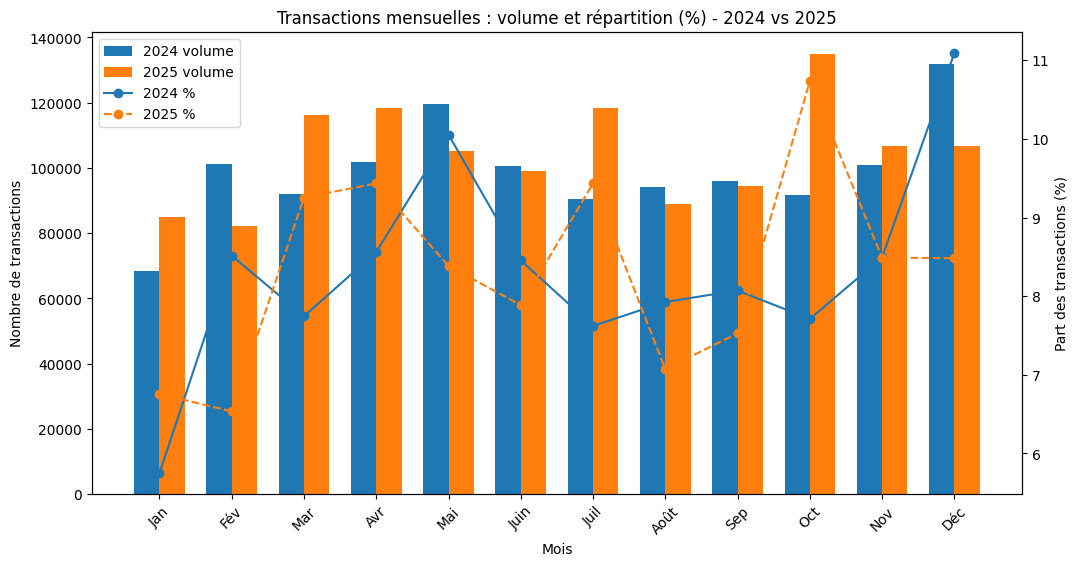

In [109]:
import matplotlib.pyplot as plt
import numpy as np

# conversion date
df["Date mutation"] = pd.to_datetime(df["Date mutation"], errors="coerce")

# extraction
df["annee"] = df["Date mutation"].dt.year
df["mois"] = df["Date mutation"].dt.month

# filtrage
df_filtered = df[df["annee"].isin([2024, 2025])]

# comptage
pivot = df_filtered.groupby(["mois", "annee"]).size().unstack(fill_value=0)

# pourcentages
pivot_pct = pivot.div(pivot.sum(axis=0), axis=1) * 100

# positions
x = np.arange(12)
width = 0.35

fig, ax1 = plt.subplots(figsize=(12,6))

# barres (volume)
ax1.bar(x - width/2, pivot[2024], width, label="2024 volume")
ax1.bar(x + width/2, pivot[2025], width, label="2025 volume")

ax1.set_xlabel("Mois")
ax1.set_ylabel("Nombre de transactions")

ax1.set_xticks(x)
ax1.set_xticklabels(["Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
                     "Juil", "Août", "Sep", "Oct", "Nov", "Déc"], rotation=45)

# axe secondaire pour %
ax2 = ax1.twinx()

ax2.plot(x, pivot_pct[2024], marker="o", linestyle="-", label="2024 %")
ax2.plot(x, pivot_pct[2025], marker="o", linestyle="--", label="2025 %")

ax2.set_ylabel("Part des transactions (%)")

# légende combinée
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels)

plt.title("Transactions mensuelles : volume et répartition (%) - 2024 vs 2025")

plt.show()

## Nature mutation
Type de transaction (vente, succession, etc.)

Cette colonne décrit le contexte juridique de la transaction immobilière.

Le graphique montre que les ventes classiques représentent la majorité des transactions, suivies des ventes en l'état futur d'achèvement (VEFA) et des ventes de terrains à bâtir.

---

### 🧠 Interprétation
- Les ventes classiques constituent le cœur du marché immobilier (biens existants)
- Les ventes en VEFA correspondent au marché du neuf et influencent les niveaux de prix
- Les ventes de terrains à bâtir représentent une catégorie spécifique du marché foncier
- Les autres types de mutations (échange, adjudication, expropriation) sont marginaux et ne reflètent pas toujours un prix de marché

---

### 🔧 Traitement
Les mutations suivantes sont conservées :
- **Vente**
- **Vente en l'état futur d'achèvement**
- **Vente terrain à bâtir**

Les autres types sont exclus car non comparables ou atypiques.

---

### ⚠️ Remarque
Les terrains à bâtir sont de nature différente des biens bâtis. Ils pourront faire l’objet d’une analyse spécifique ou être distingués dans les analyses de prix.

---

### ✔️ Conclusion
Le dataset est filtré pour inclure les principales catégories de transactions du marché immobilier (ancien, neuf et foncier), tout en conservant une cohérence d’analyse.

In [110]:
df["Nature mutation"].value_counts()

Nature mutation
Vente                                 6773005
Vente en l'état futur d'achèvement     314254
Echange                                 92974
Vente terrain à bâtir                   15616
Adjudication                            14658
Expropriation                            4253
Nature mutation                             1
Name: count, dtype: int64

In [111]:
df["Nature mutation"].value_counts(normalize=True) * 100

Nature mutation
Vente                                 93.877053
Vente en l'état futur d'achèvement     4.355709
Echange                                1.288664
Vente terrain à bâtir                  0.216445
Adjudication                           0.203167
Expropriation                          0.058949
Nature mutation                        0.000014
Name: proportion, dtype: float64

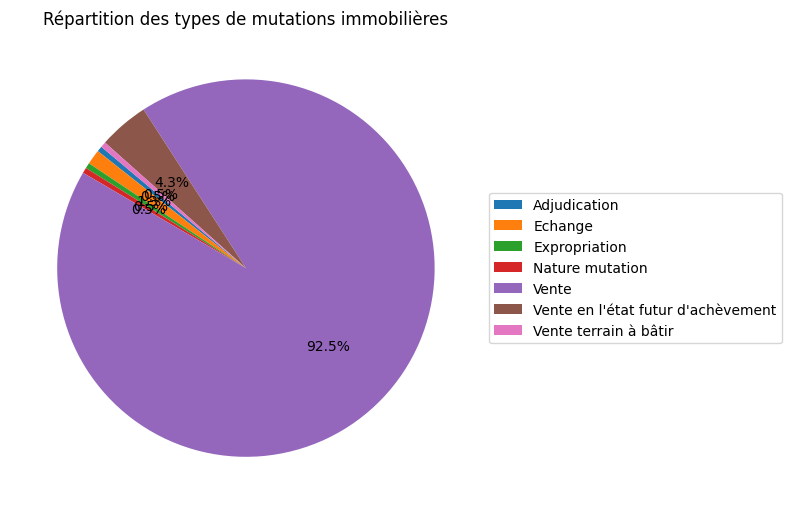

In [112]:
import matplotlib.pyplot as plt

# comptage
counts = df["Nature mutation"].value_counts()

# regrouper les petites catégories
threshold = 50000  # ajustable
counts_clean = counts.copy()
counts_clean[counts < threshold] = counts[counts < threshold].sum()
counts_clean = counts_clean.groupby(counts_clean.index).sum()

# labels propres
labels = counts_clean.index
sizes = counts_clean.values

# graphique
plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=None,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Répartition des types de mutations immobilières")

# légende à droite
plt.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## Adresse
Informations de localisation du bien.
## Analyse des colonnes d’adresse

Les colonnes d’adresse présentent des niveaux de complétude variables :

- No voie : ~36% de valeurs manquantes  
- Type de voie : ~39% de valeurs manquantes  
- Voie : ~0,6% de valeurs manquantes  
- B/T/Q : ~95% de valeurs manquantes  

---

### 🧠 Interprétation

Ces variables décrivent l’adresse fine du bien immobilier.  
La colonne "Voie" est la plus fiable et la plus complète du bloc adresse.

---

### 🔧 Traitement

- No voie : supprimée  
- Type de voie : supprimée  
- B/T/Q : supprimée  
- Voie : conservée pour l’instant

---

### ⚠️ Remarque
La colonne "Voie" est conservée à titre descriptif, mais ne sera pas utilisée comme variable explicative principale dans l’analyse du marché immobilier.

---

### ✔️ Conclusion
L’analyse principale se concentre sur des variables de localisation agrégées (code postal, commune, département), plus robustes et exploitables statistiquement.

In [30]:
df[["No voie", "Type de voie", "Voie", "B/T/Q"]].head(10)

,No voie,Type de voie,Voie,B/T/Q
0,NaN,NaN,LE DELIVRE,NaN
1,NaN,NaN,CHEVRY DESSOUS,NaN
2,NaN,NaN,PIN HAMEAU,NaN
3,29,PL,DU JURA,NaN
4,9001,PL,DU JURA,NaN
5,29,PL,DU JURA,NaN
6,29,PL,DU JURA,NaN
7,NaN,NaN,AU CHAUME,NaN
8,NaN,NaN,LES FATES,NaN
9,NaN,NaN,LES FATES,NaN


In [113]:
df[["No voie", "Type de voie", "Voie", "B/T/Q"]].isna().mean() * 100

No voie         36.750601
Type de voie    38.762739
Voie             0.597580
B/T/Q           95.516719
dtype: float64

## Code postal ET Commune
 Localisation géographique
 Analyse des variables géographiques

Les variables "Code postal" et "Commune" permettent d’identifier la localisation des biens.
Qualité des données
- Code postal : 0,60% de valeurs manquantes
- Commune : 0% de valeurs manquantes
- Code département : 0% de valeurs manquantes
- Code commune : 0% de valeurs manquantes

---

### 📊 Observations
Les données présentent une excellente complétude et une forte granularité géographique avec plus de 31 000 communes représentées.

Les zones les plus actives sont les grandes métropoles françaises (Toulouse, Nice, Montpellier, Bordeaux, Nantes).

---

### 🧠 Interprétation
Les variables géographiques sont cohérentes et reflètent correctement la structure du marché immobilier français, dominé par les zones urbaines.

---

### ✔️ Décision
Toutes les variables géographiques sont conservées pour les analyses spatiales et les agrégations de marché.

In [114]:
cols_geo = ["Code postal", "Commune", "Code departement", "Code commune"]

df[cols_geo].isna().mean() * 100

Code postal         0.603637
Commune             0.000000
Code departement    0.000000
Code commune        0.000000
dtype: float64

In [115]:
df["Commune"].value_counts().head(10)

Commune
TOULOUSE         47159
NICE             41605
MONTPELLIER      27334
BORDEAUX         27136
NANTES           27102
SAINT-ETIENNE    19687
RENNES           19678
LILLE            18839
DIJON            18009
TOULON           17755
Name: count, dtype: int64

In [116]:
df["Commune"].nunique()

31325

In [37]:
df["Code postal"].value_counts().head(10)

Code postal
21000    17903
75015    17133
75016    15533
06000    14696
29200    14119
89000    13658
51100    13645
75018    13439
54000    13224
75017    12997
Name: count, dtype: int64

In [38]:
df[["Code postal", "Commune"]].isna().mean() * 100

Code postal    0.603637
Commune        0.000000
dtype: float64

In [39]:
# nombre de communes pour un même code postal
df.groupby("Code postal")["Commune"].nunique().sort_values(ascending=False).head(10)

Code postal
51300    46
51800    44
70000    42
88500    42
80140    39
10500    36
70100    36
70500    36
39570    36
65100    36
Name: Commune, dtype: int64

## Données cadastrales
Analyse des colonnes

- Prefixe de section : ~95% de valeurs manquantes  
- Section : quasi entièrement renseignée  
- No plan : entièrement renseigné  
- No volume : ~99,7% de valeurs manquantes  

---

### 🧠 Interprétation

Ces variables correspondent à des identifiants cadastraux permettant de localiser précisément les parcelles immobilières.

Cependant :
- certaines colonnes sont fortement incomplètes (Prefixe de section, No volume)
- d’autres sont bien renseignées mais très techniques (Section, No plan)
- elles ne sont pas directement interprétables dans une analyse économique

---

### 🔧 Traitement

- Prefixe de section : supprimée  
- No volume : supprimée  
- Section : conservée (optionnel)  
- No plan : conservée (optionnel)

---

### ✔️ Conclusion
Ces variables sont principalement administratives et seront peu utilisées dans l’analyse statistique globale du marché immobilier.

In [117]:
cols_cadastre = ["Prefixe de section", "Section", "No plan", "No Volume"]

df[cols_cadastre].isna().mean() * 100

Prefixe de section    95.139312
Section                0.004172
No plan                0.000000
No Volume             99.764802
dtype: float64

In [118]:
df[cols_cadastre].head()

,Prefixe de section,Section,No plan,No Volume
0,NaN,B,514,NaN
1,NaN,B,1782,NaN
2,NaN,C,1065,NaN
3,NaN,AI,551,NaN
4,NaN,AI,551,NaN


## LOTS
Analyse des colonnes

- Les identifiants de lots (1er à 5e lot) sont fortement incomplets :
  - 1er lot : ~69% de valeurs manquantes
  - 2e lot : ~90% de valeurs manquantes
  - 3e à 5e lot : jusqu’à ~99% de valeurs manquantes

- Les surfaces Carrez associées sont également très peu renseignées (jusqu’à ~99,9% de valeurs manquantes)

- La variable "Nombre de lots" est entièrement renseignée

---

### 🧠 Interprétation

Les informations détaillées sur les lots sont trop incomplètes pour être exploitées de manière fiable dans une analyse globale.

En revanche, le "Nombre de lots" est une variable robuste permettant de caractériser la structure des biens immobiliers (mono-bien vs copropriété).

---

### 🔧 Traitement

- Les colonnes détaillées des lots et surfaces sont supprimées  
- La variable "Nombre de lots" est conservée  

---

### ✔️ Conclusion
L’analyse se concentre sur des variables synthétiques fiables permettant de caractériser la structure des biens sans introduire de bruit.

In [119]:
lot_cols = [
    "1er lot","2eme lot","3eme lot","4eme lot","5eme lot",
    "Surface Carrez du 1er lot","Surface Carrez du 2eme lot",
    "Surface Carrez du 3eme lot","Surface Carrez du 4eme lot",
    "Surface Carrez du 5eme lot","Nombre de lots"
]

df[lot_cols].isna().mean() * 100

1er lot                       69.242197
2eme lot                      90.586729
3eme lot                      98.344505
4eme lot                      99.455630
5eme lot                      99.747878
Surface Carrez du 1er lot     90.864992
Surface Carrez du 2eme lot    97.043021
Surface Carrez du 3eme lot    99.672837
Surface Carrez du 4eme lot    99.917572
Surface Carrez du 5eme lot    99.970408
Nombre de lots                 0.000000
dtype: float64

## Code type local/ Type local
ype de local

### 📊 Observations
La colonne présente une part importante de valeurs manquantes (~2,9 millions de lignes), correspondant principalement à des lignes techniques ou secondaires dans les transactions DVF.

Les catégories principales sont :
- Maison
- Appartement
- Dépendance
- Local industriel ou commercial

---

### 🧠 Interprétation
Les valeurs manquantes ne correspondent pas nécessairement à des erreurs, mais à des lignes sans typologie principale (structure multi-lots des transactions DVF).

---

### 🔧 Traitement
Seuls les biens principaux sont conservés pour l’analyse :
- Maison
- Appartement
- Local industriel/commercial

Les lignes sans type de bien sont exclues.

---

### ✔️ Conclusion
Le dataset est filtré pour conserver uniquement les biens immobiliers exploitables dans une analyse de marché cohérente.

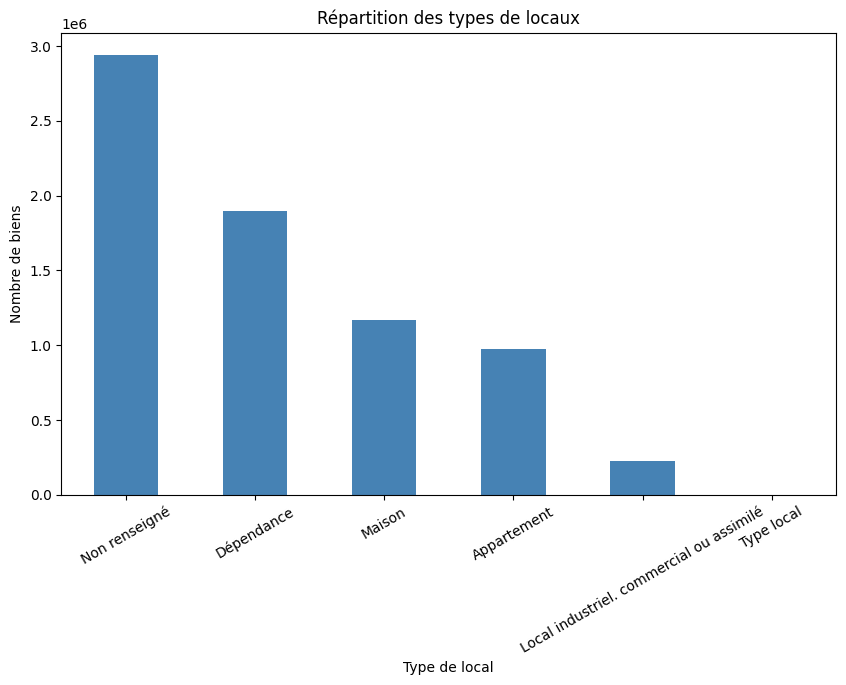

In [123]:
import matplotlib.pyplot as plt

# comptage des types
counts = df["Type local"].value_counts(dropna=False)

# remplacement du NaN pour lisibilité
counts.index = counts.index.fillna("Non renseigné")

plt.figure(figsize=(10,6))

counts.plot(kind="bar", color="steelblue")

plt.title("Répartition des types de locaux")
plt.xlabel("Type de local")
plt.ylabel("Nombre de biens")

plt.xticks(rotation=30)

plt.show()

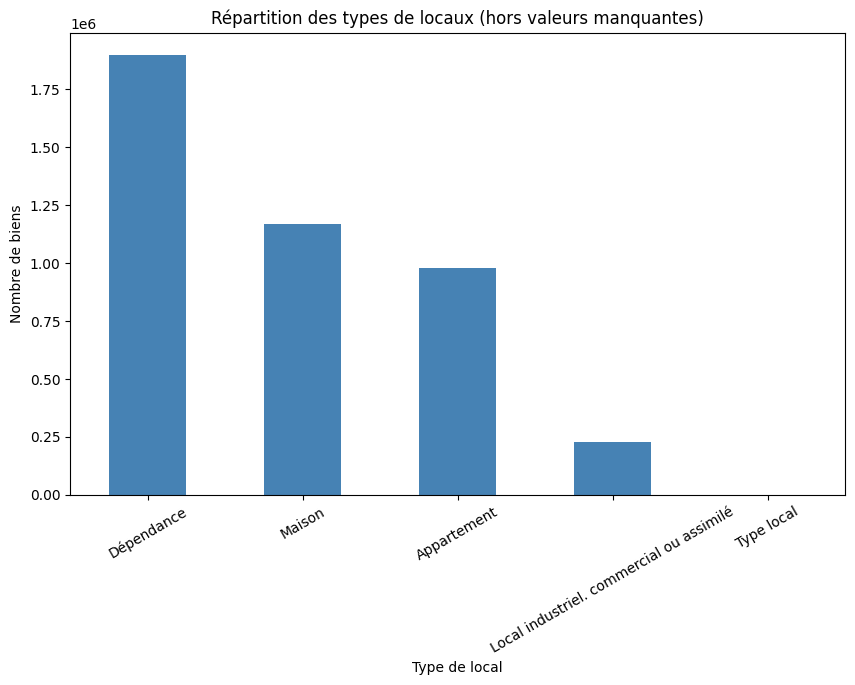

In [124]:
counts = df["Type local"].value_counts()

plt.figure(figsize=(10,6))

counts.plot(kind="bar", color="steelblue")

plt.title("Répartition des types de locaux (hors valeurs manquantes)")
plt.xlabel("Type de local")
plt.ylabel("Nombre de biens")

plt.xticks(rotation=30)

plt.show()

## Surfaces
## Analyse des surfaces

L’analyse des surfaces permet de comprendre la taille des biens immobiliers dans la base de données DVF.

Deux types de surfaces sont étudiés :
- la surface bâtie (surface des constructions)
- la surface du terrain

### 1. Surface bâtie

Les statistiques observées sont les suivantes :
- Surface moyenne : 65.24 m²
- Surface minimale : 0 m²
- Surface maximale : 646 230 m²

La médiane est de 30 m², ce qui indique que la majorité des transactions concernent des biens de petite taille ou partiellement renseignés.
La moyenne (65 m²) est supérieure à la médiane, ce qui confirme une distribution asymétrique à droite.
De nombreuses valeurs nulles (0 m²) sont présentes, probablement liées à des données manquantes ou mal renseignées.
Des valeurs extrêmes irréalistes (jusqu’à 646 230 m²) suggèrent des erreurs ou des cas atypiques non représentatifs du marché résidentiel.

👉 Interprétation :
La surface moyenne correspond à des biens résidentiels classiques (appartements ou petites maisons).
La présence d’une valeur maximale très élevée indique la présence de valeurs extrêmes (probablement des biens atypiques, erreurs ou ensembles immobiliers).

### 2. Surface du terrain

Les statistiques observées sont les suivantes :
Surface terrain moyenne : 3382.453297265249
Surface terrain min : 0.0
Surface terrain max : 252611540.0

La distribution est encore plus dispersée que celle de la surface bâtie.
La médiane (646 m²) est très inférieure à la moyenne (3 382 m²), indiquant une forte asymétrie.
Des valeurs extrêmes très élevées (jusqu’à 252 millions de m²) confirment la présence d’outliers majeurs ou d’erreurs de saisie.

👉 Interprétation :
La surface du terrain présente une forte variabilité. Les valeurs nulles correspondent généralement à des appartements, tandis que les grandes surfaces correspondent à des maisons individuelles ou terrains.

### Conclusion

Les surfaces présentent une grande dispersion, avec des valeurs extrêmes importantes. Une analyse des outliers pourra être réalisée pour affiner l’étude.

Ces deux variables nécessitent un traitement approfondi avant toute modélisation :

gestion des valeurs nulles (0)
suppression ou cap des outliers
transformation potentielle (log ou winsorisation)

In [125]:
df["Surface reelle bati"] = pd.to_numeric(df["Surface reelle bati"], errors="coerce")
df["Surface terrain"] = pd.to_numeric(df["Surface terrain"], errors="coerce")

In [126]:
df[["Surface reelle bati", "Surface terrain"]].isna().mean() * 100

Surface reelle bati    40.840535
Surface terrain        31.222989
dtype: float64

In [127]:
df[["Surface reelle bati", "Surface terrain"]].describe()

,Surface reelle bati,Surface terrain
count,4.268214e+06,4.962097e+06
mean,6.523721e+01,3.382453e+03
std,1.110530e+03,1.190795e+05
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,2.570000e+02
50%,3.000000e+01,6.460000e+02
75%,8.000000e+01,1.926000e+03
max,6.462300e+05,2.526115e+08


In [128]:
print("Surface bâtie moyenne :", df["Surface reelle bati"].mean())
print("Surface bâtie min :", df["Surface reelle bati"].min())
print("Surface bâtie max :", df["Surface reelle bati"].max())

Surface bâtie moyenne : 65.23720553842895
Surface bâtie min : 0.0
Surface bâtie max : 646230.0


In [129]:
print("Surface terrain moyenne :", df["Surface terrain"].mean())
print("Surface terrain min :", df["Surface terrain"].min())
print("Surface terrain max :", df["Surface terrain"].max())

Surface terrain moyenne : 3382.453297265249
Surface terrain min : 0.0
Surface terrain max : 252611540.0


In [130]:
df["Surface reelle bati"].sort_values(ascending=False).head(5)

4704448    646230.0
4704286    646230.0
4704151    646230.0
4703995    646230.0
4703908    646230.0
Name: Surface reelle bati, dtype: float64

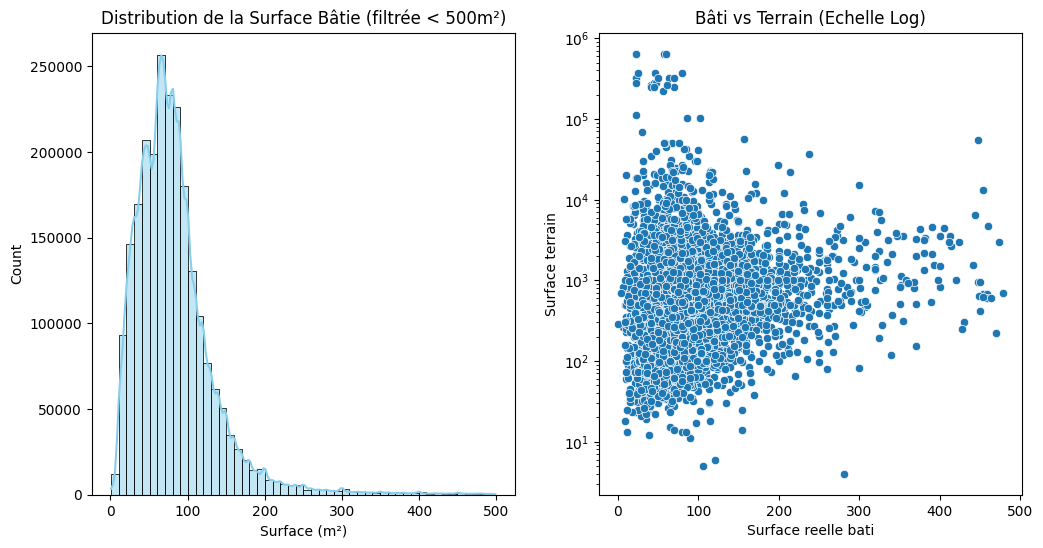

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# On filtre les données pour la visualisation (ex: batiment < 500m2)
mask_view = (df["Surface reelle bati"] > 0) & (df["Surface reelle bati"] < 500)

plt.figure(figsize=(12, 6))

# Histogramme de la surface bâtie
plt.subplot(1, 2, 1)
sns.histplot(df[mask_view]["Surface reelle bati"], bins=50, kde=True, color="skyblue")
plt.title("Distribution de la Surface Bâtie (filtrée < 500m²)")
plt.xlabel("Surface (m²)")

# Relation Bâti vs Terrain (en log pour y voir quelque chose)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df[mask_view].sample(10000), x="Surface reelle bati", y="Surface terrain")
plt.yscale('log')
plt.title("Bâti vs Terrain (Echelle Log)")
plt.show()

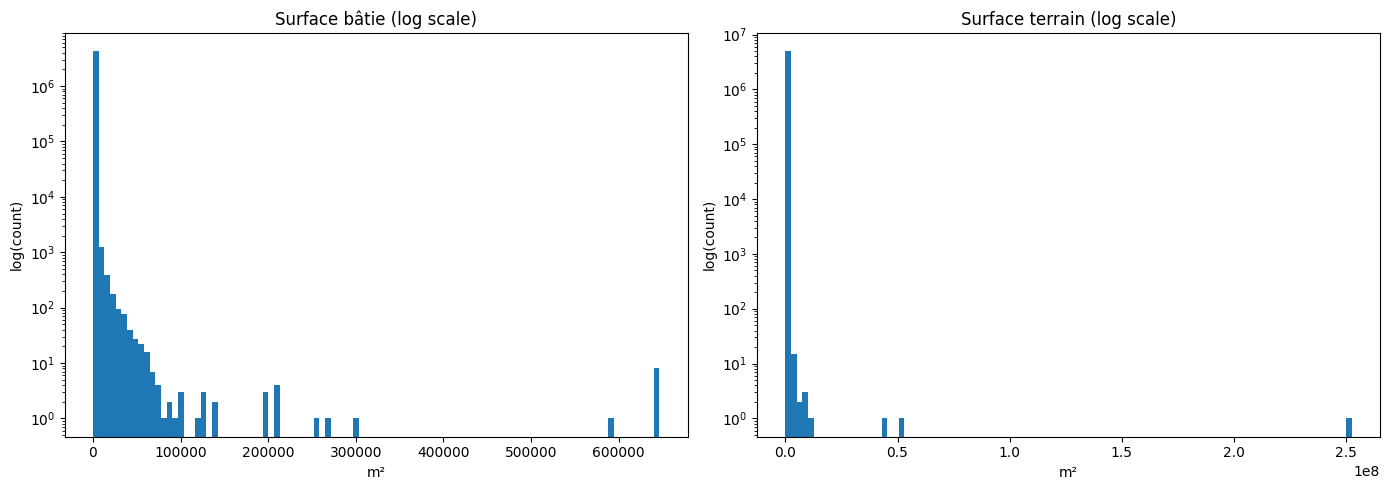

In [132]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Surface bâtie
axes[0].hist(df["Surface reelle bati"].dropna(), bins=100, log=True)
axes[0].set_title("Surface bâtie (log scale)")
axes[0].set_xlabel("m²")
axes[0].set_ylabel("log(count)")

# Surface terrain
axes[1].hist(df["Surface terrain"].dropna(), bins=100, log=True)
axes[1].set_title("Surface terrain (log scale)")
axes[1].set_xlabel("m²")
axes[1].set_ylabel("log(count)")

plt.tight_layout()
plt.show()

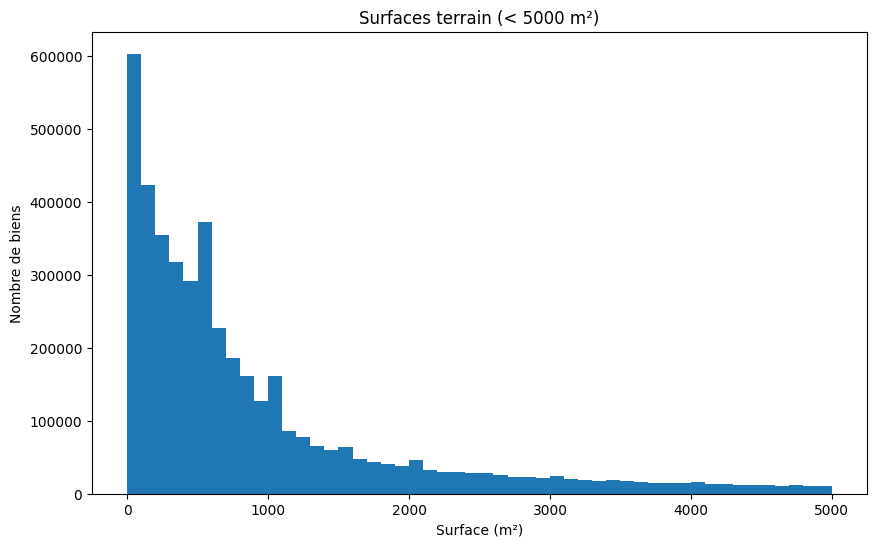

In [52]:
plt.figure(figsize=(10,6))
plt.hist(df[df["Surface terrain"] < 5000]["Surface terrain"].dropna(), bins=50)

plt.title("Surfaces terrain (< 5000 m²)")
plt.xlabel("Surface (m²)")
plt.ylabel("Nombre de biens")

plt.show()

## Nombre de pièces
Dans cette partie, nous analysons la répartition des différents types de biens présents dans la base DVF.

La distribution du nombre de pièces principales met en évidence une structure typique du marché immobilier résidentiel, fortement concentrée sur les petites typologies.

📊 Distribution observée
Les logements de 1 à 3 pièces représentent la majorité des transactions.
Les biens de 4 à 5 pièces sont moins fréquents mais correspondent aux logements familiaux standards.
Les biens de plus de 6 pièces sont marginaux et souvent associés à des maisons ou biens atypiques.
Une queue longue est observée avec des valeurs supérieures à 20 pièces, probablement liées à des erreurs ou à des immeubles entiers.
⚠️ Qualité des données
Des valeurs élevées (>10 pièces) peuvent correspondre à des anomalies ou des biens non résidentiels.
Les valeurs extrêmes doivent être filtrées pour éviter des biais statistiques.
🔗 Cohérence avec la surface

Cette variable doit être interprétée conjointement avec la surface bâtie :

Une forte incohérence entre surface et nombre de pièces peut indiquer des erreurs de saisie.
Le ratio surface / pièce est un indicateur pertinent pour détecter les anomalies et caractériser la qualité des biens.


Score de cohérence :

🟢 Zone “saine” (1 à 10 pièces)
scores entre 0.98 et 0.999
très stable
quasi toutes les observations sont cohérentes

👉 conclusion :

les logements “classiques” DVF sont globalement fiables

🟠 Zone intermédiaire (11 à 19 pièces)
baisse progressive :
0.97 → 0.82
plus de bruit

👉 conclusion :

on commence à sortir du résidentiel standard

🔴 Zone critique (20+ pièces)
chute brutale :
20 pièces → 0.47
24 pièces → 0.07
80+ pièces → 0
198 pièces → 0

👉 conclusion :

ces lignes sont quasi certainement :

immeubles entiers
erreurs DVF
locaux commerciaux / atypiques
agrégations de lots

plus le nombre de pièces augmente, plus la donnée devient non fiable

Ce n’est pas juste du bruit :
👉 c’est une rupture structurelle du dataset

ésultats observés
Pour les logements entre 1 et 10 pièces, le score est très élevé (≈ 0.98 à 1.00), indiquant une forte cohérence entre surface et typologie.
À partir de 11 pièces, une dégradation progressive du score est observée.
Au-delà de 20 pièces, le score chute fortement, atteignant des valeurs proches de zéro pour les cas extrêmes.
⚠️ Interprétation

Cette dégradation met en évidence plusieurs phénomènes :

les grandes valeurs de pièces sont rarement représentatives de logements standards
elles correspondent probablement à des biens atypiques (immeubles entiers, locaux commerciaux)
certaines observations peuvent être issues d’erreurs de saisie ou d’agrégations de lots
📉 Conclusion

Le score de cohérence confirme que :

les logements résidentiels standards (1 à 10 pièces) sont globalement fiables dans DVF
les observations au-delà de 10 pièces présentent une qualité de données fortement dégradée
les valeurs extrêmes doivent être traitées avec prudence ou exclues des analyses
🎯 Intérêt analytique

Ce score permet de :

détecter automatiquement les anomalies structurelles
filtrer les données non exploitables
améliorer la robustesse des analyses de prix immobiliers
préparer un dataset fiable pour la modélisation

🎯 Intérêt analytique

Cette variable est essentielle pour :

segmenter le marché immobilier
expliquer les différences de prix
détecter des incohérences dans les données DVF
enrichir les modèles de valorisation immobilière



OPTION DE NETTOYAGE
garder uniquement logement “résidentiel standard”

df_clean = df[df["Nombre pieces principales"].between(1, 10)]

✔ propre
✔ stable
✔ idéal pour prix au m²


OU
OPTION 2 : garder mais pondérer

Si tu veux garder tout DVF :

df["poids_coherence"] = df["score_coherence"]

👉 utile pour modèles ML


OPTION 3 : split dataset (très pro)
df_residentiel = df[df["Nombre pieces principales"] <= 10]
df_atypique = df[df["Nombre pieces principales"] > 10]

✔ meilleure pratique data science

In [133]:
df["Nombre pieces principales"] = pd.to_numeric(
    df["Nombre pieces principales"],
    errors="coerce"
)

In [134]:
df["Nombre pieces principales"].describe()

count    4.268214e+06
mean     1.733835e+00
std      2.064070e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      1.980000e+02
Name: Nombre pieces principales, dtype: float64

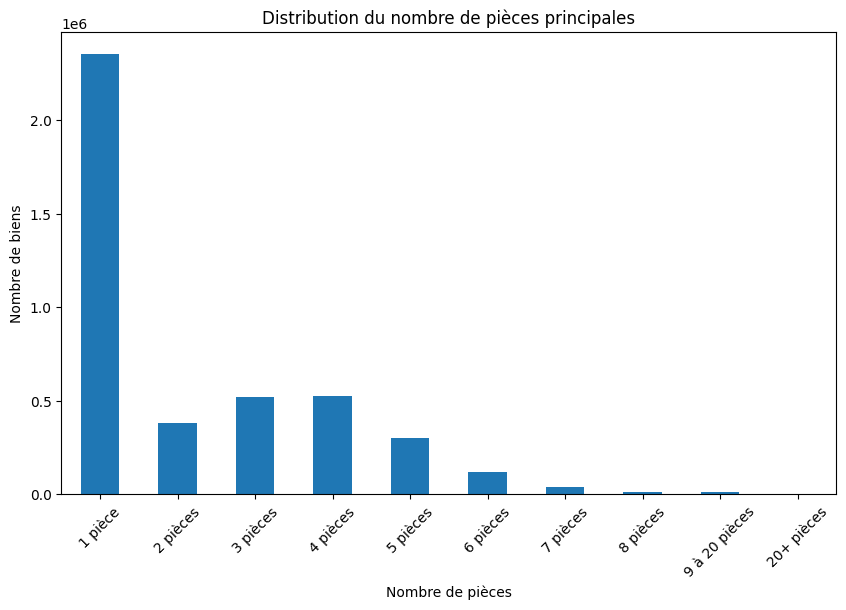

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

s = df["Nombre pieces principales"].dropna()

# bins corrigés (1 à 7 + 8-20 + 20+)
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 20, np.inf]

labels = [
    "1 pièce", "2 pièces", "3 pièces", "4 pièces",
    "5 pièces", "6 pièces", "7 pièces",
    "8 pièces", "9 à 20 pièces", "20+ pièces"
]

cat = pd.cut(s, bins=bins, labels=labels, include_lowest=True)

counts = cat.value_counts().sort_index()

plt.figure(figsize=(10,6))

counts.plot(kind="bar")

plt.title("Distribution du nombre de pièces principales")
plt.xlabel("Nombre de pièces")
plt.ylabel("Nombre de biens")

plt.xticks(rotation=45)
plt.show()

In [135]:
df["surface_par_piece"] = df["Surface reelle bati"] / df["Nombre pieces principales"]

In [136]:
df = df[df["Nombre pieces principales"] > 0]

<Figure size 1000x600 with 0 Axes>

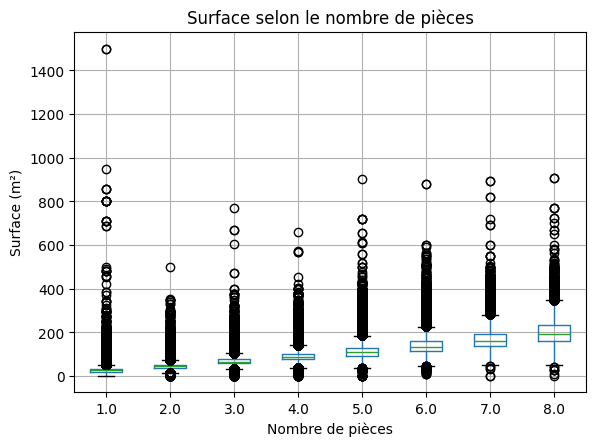

In [137]:
import matplotlib.pyplot as plt

df_clean = df[df["Nombre pieces principales"] <= 8]

plt.figure(figsize=(10,6))
df_clean.boxplot(column="Surface reelle bati", by="Nombre pieces principales")

plt.title("Surface selon le nombre de pièces")
plt.suptitle("")
plt.xlabel("Nombre de pièces")
plt.ylabel("Surface (m²)")
plt.show()

In [138]:
def coherence_score(x):
    if pd.isna(x):
        return np.nan
    if 10 <= x <= 80:
        return 1
    else:
        return 0

df["score_coherence"] = df["surface_par_piece"].apply(coherence_score)

In [139]:
df["score_coherence"].value_counts(normalize=True)

score_coherence
1    0.995093
0    0.004907
Name: proportion, dtype: float64

In [140]:
df.groupby("Nombre pieces principales")["score_coherence"].mean()

Nombre pieces principales
1.0      0.975658
2.0      0.993974
3.0      0.997359
4.0      0.998946
5.0      0.999267
6.0      0.998860
7.0      0.998509
8.0      0.997152
9.0      0.995957
10.0     0.987721
11.0     0.977586
12.0     0.943563
13.0     0.925081
14.0     0.838889
15.0     0.900662
16.0     0.842857
17.0     0.916667
18.0     0.857143
19.0     0.823529
20.0     0.473684
21.0     0.684211
22.0     0.428571
23.0     0.600000
24.0     0.071429
25.0     0.000000
26.0     0.250000
27.0     1.000000
28.0     0.250000
29.0     0.000000
30.0     0.000000
31.0     0.000000
32.0     0.166667
33.0     0.000000
34.0     0.000000
35.0     0.000000
36.0     0.000000
39.0     1.000000
41.0     0.000000
43.0     0.000000
44.0     0.000000
46.0     0.000000
50.0     0.000000
53.0     0.000000
55.0     0.000000
64.0     0.000000
70.0     0.000000
73.0     0.000000
77.0     0.000000
82.0     0.000000
83.0     0.000000
89.0     0.000000
92.0     0.000000
198.0    0.000000
Name: score_coherenc

## NATURE

Urbain / sols (marché immobilier principal)
S : sols urbains / terrains constructibles ou urbains

👉 utilisé pour :

parcelles urbaines
foncier constructible
zones bâties
🏠 Bâti (souvent via NaN dans DVF)
NaN : généralement biens déjà bâtis (maisons, appartements)

👉 interprétation :

absence de code = souvent logement construit
🌾 Agricole
AG : terres agricoles
P : prés
PA : pâtures
PP : peupleraies / prés spécialisés
PH : prairies humides
VI / V : vignes

👉 correspond à :

exploitation agricole
terres cultivées
viticulture
🌲 Naturel / forestier
B : bois
BR : broussailles
BO : bois divers
BF : forêt
L : landes

👉 correspond à :

espaces naturels
forêts
terrains non constructibles
🏡 Annexes / jardins / divers liés à l’habitat
J : jardins
E : espaces divers
BT : bâti secondaire
BP : petites dépendances

👉 correspond à :

extension de logements
zones annexes résidentielles
⚪ Cas rares / peu fréquents
CA : carrières / zones spécifiques
CH : cas particuliers
TP : terrains particuliers
PE : parcelles exceptionnelles
BM, LB, etc. : codes très rares

👉 correspond à :

cas atypiques
anomalies DVF
usages spécifiques 

Synthèse des regroupements possibles
🟢 1. Marché immobilier résidentiel
S
NaN (bâti)
🌾 2. Agricole
AG, P, PA, PP, PH, V, VI
🌲 3. Naturel
B, BR, BO, BF, L
🏡 4. Annexes / jardins
J, E, BT, BP
⚪ 5. Bruit / cas rares
CA, CH, TP, PE, etc.
🎯 Conclusion métier

👉 Cette variable permet de :

distinguer immobilier vs non immobilier
isoler le marché résidentiel réel
filtrer les terrains agricoles / naturels
améliorer fortement la qualité des analyses de prix

In [144]:
df["Nature culture"].isna().sum()

np.int64(806085)

In [145]:
df["Nature culture"].isna().mean()

np.float64(0.3764003207003483)

In [146]:
df["Nature culture"].head()

5     NaN
77      S
80      S
81      S
82      S
Name: Nature culture, dtype: str

In [147]:
df["Nature culture"].value_counts(dropna=False)

Nature culture
S      1117193
NaN     806085
AG       79017
J        52017
T        30739
P        20597
AB        7007
VE        6459
L         6292
BT        4664
BR        2838
B         2200
VI        1368
E         1190
PA        1117
BS         992
PP         652
BF         337
BP         282
PH         195
PC         128
BM          64
CH          63
CA          31
LB          19
TP           9
PE           7
BO           1
Name: count, dtype: int64

In [148]:
df["nature_group"] = df["Nature culture"].apply(lambda x: (
    "urbain_residentiel" if (x == "S" or pd.isna(x)) else
    "agricole" if x in ["AG", "P", "PA", "PP", "PH", "V", "VI"] else
    "naturel" if x in ["B", "BR", "BO", "BF", "L"] else
    "jardin_annexes" if x in ["J", "E", "BT", "BP"] else
    "rare"
))

In [149]:
counts = df["nature_group"].value_counts()

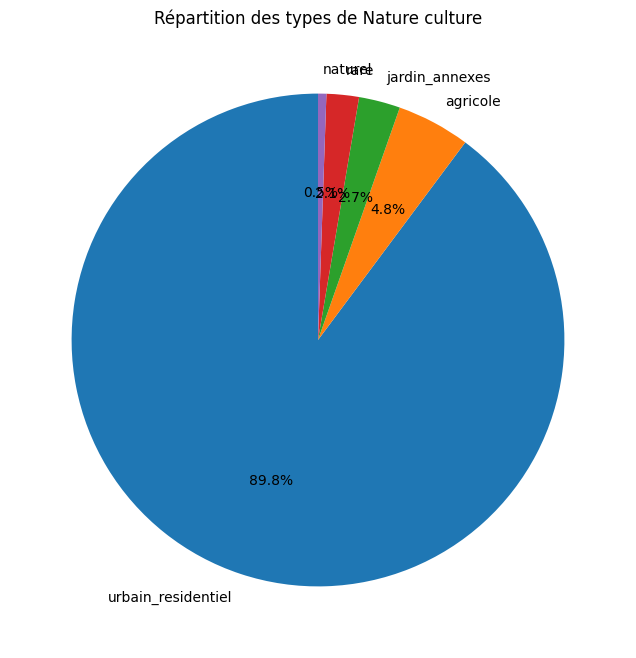

In [150]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des types de Nature culture")
plt.ylabel("")  # enlever label inutile
plt.show()